In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\tedvm\Centrale\PoleProjetS8\Data_PublicHealth_CentraleSupelec\data\google_trends\all_keywords_merged.csv")

df.head()

,date,journee mondiale sans tabac,journee mondiale du handicap,journee mondiale de lutte contre le cancer,movember,mars bleu,world health day,juin vert,mois sans tabac,journee mondiale de la sante mentale,octobre rose,dry january,journee nationale des aidants,journee mondiale de la trisomie 21,sidaction,journee mondiale de lutte contre lobesite
0,2016-01-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2016-01-02,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2016-01-03,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2016-01-04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2016-01-05,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
#infos sur le dataframe
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3654 entries, 2016-01-01 to 2026-01-01
Data columns (total 15 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   journee mondiale sans tabac                 3654 non-null   int64
 1   journee mondiale du handicap                3654 non-null   int64
 2   journee mondiale de lutte contre le cancer  3654 non-null   int64
 3   movember                                    3654 non-null   int64
 4   mars bleu                                   3654 non-null   int64
 5   world health day                            3654 non-null   int64
 6   juin vert                                   3654 non-null   int64
 7   mois sans tabac                             3654 non-null   int64
 8   journee mondiale de la sante mentale        3654 non-null   int64
 9   octobre rose                                3654 non-null   int64
 10  dry january       

In [15]:
#traitement de la colonne date pour en faire un index temporel
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date")
    df = df.set_index("date")
else:
    # Date is already the index, just ensure it's sorted
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    
df.head()

,journee mondiale sans tabac,journee mondiale du handicap,journee mondiale de lutte contre le cancer,movember,mars bleu,world health day,juin vert,mois sans tabac,journee mondiale de la sante mentale,octobre rose,dry january,journee nationale des aidants,journee mondiale de la trisomie 21,sidaction,journee mondiale de lutte contre lobesite
date,,,,,,,,,,,,,,,
2016-01-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2016-01-02,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2016-01-03,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2016-01-04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2016-01-05,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [16]:
#doublons
df.index.duplicated().sum()

np.int64(0)

In [17]:
df.describe()

,journee mondiale sans tabac,journee mondiale du handicap,journee mondiale de lutte contre le cancer,movember,mars bleu,world health day,juin vert,mois sans tabac,journee mondiale de la sante mentale,octobre rose,dry january,journee nationale des aidants,journee mondiale de la trisomie 21,sidaction,journee mondiale de lutte contre lobesite
count,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000
mean,0.438424,0.354680,0.164204,4.628626,6.241379,0.721675,2.545703,5.071702,0.571155,11.270115,1.984674,0.321565,0.562397,3.237822,0.453202
std,6.384214,5.936896,4.049430,14.903734,20.196022,8.271600,13.337374,15.642261,7.314285,23.201202,10.628113,5.616817,7.268449,14.200958,6.649397
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


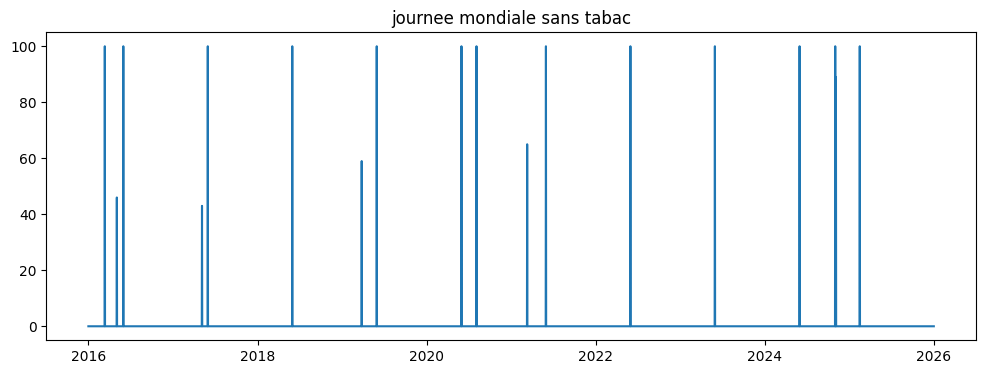

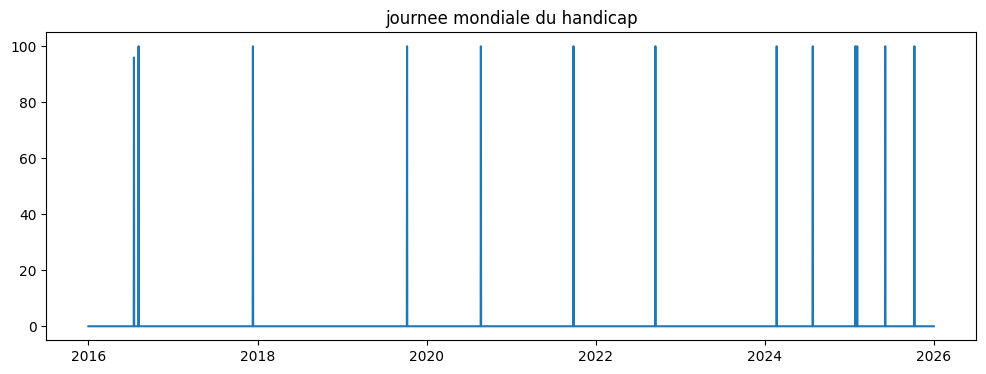

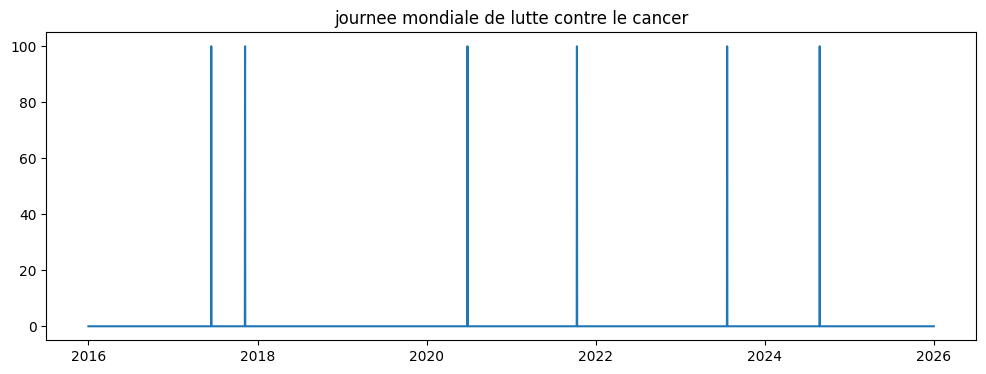

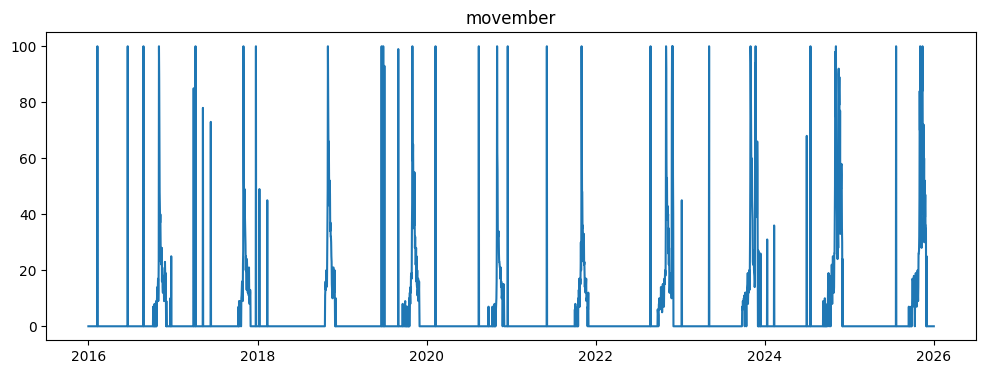

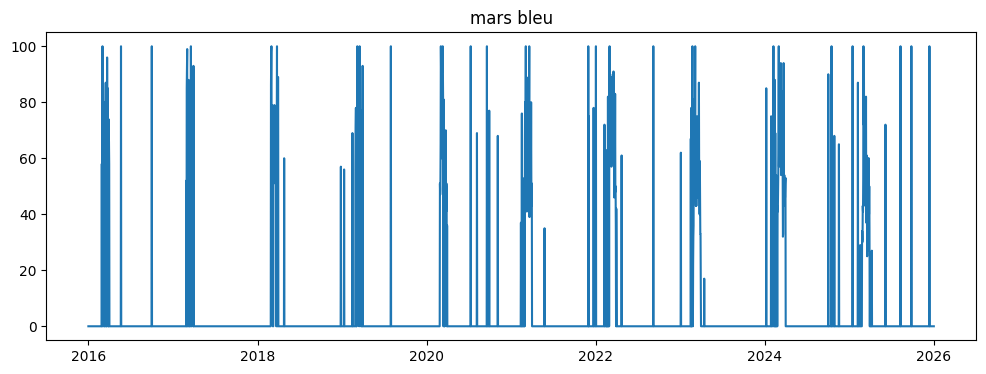

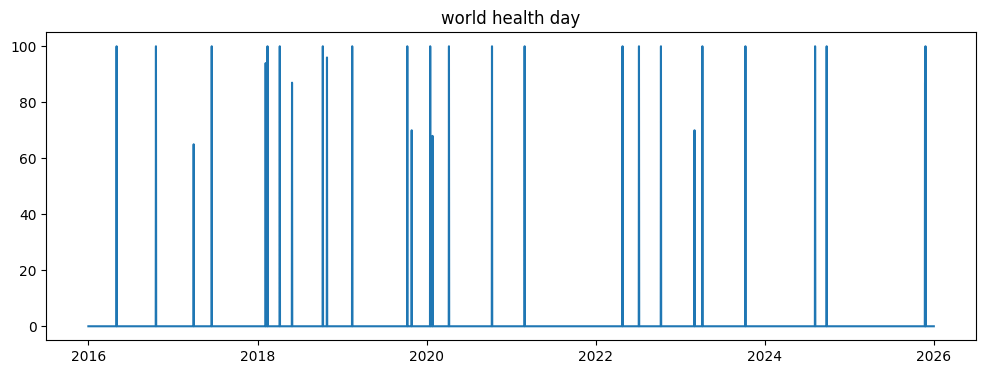

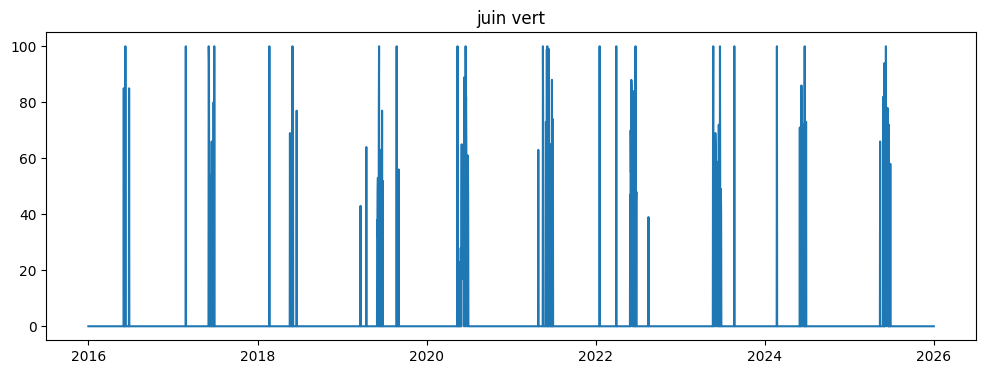

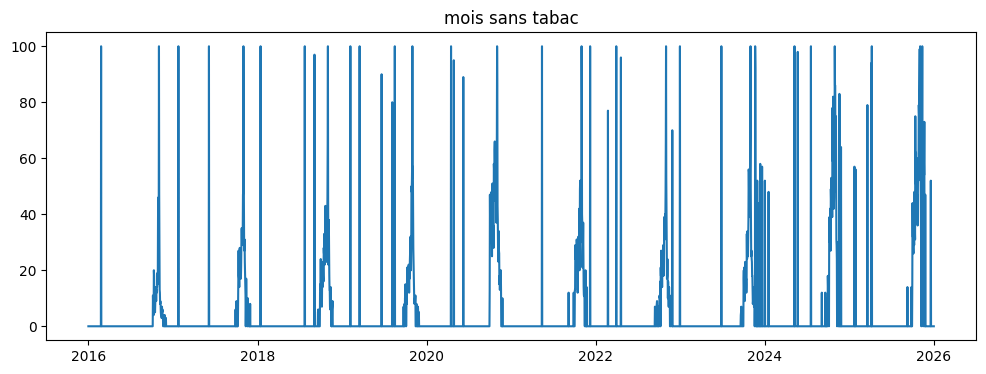

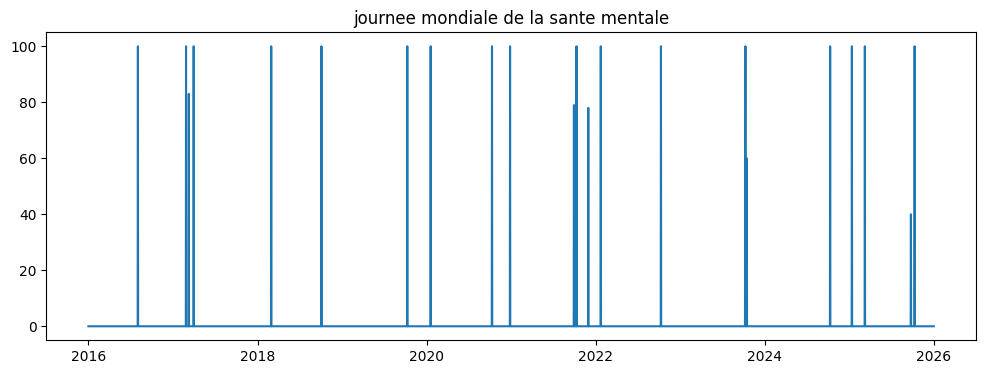

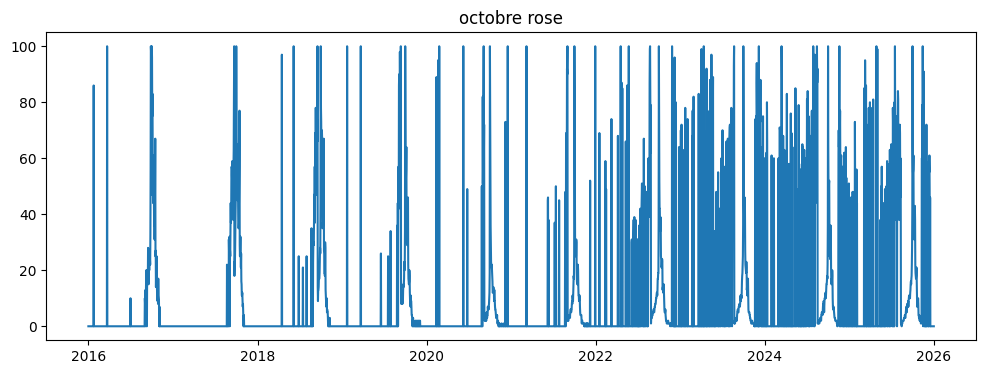

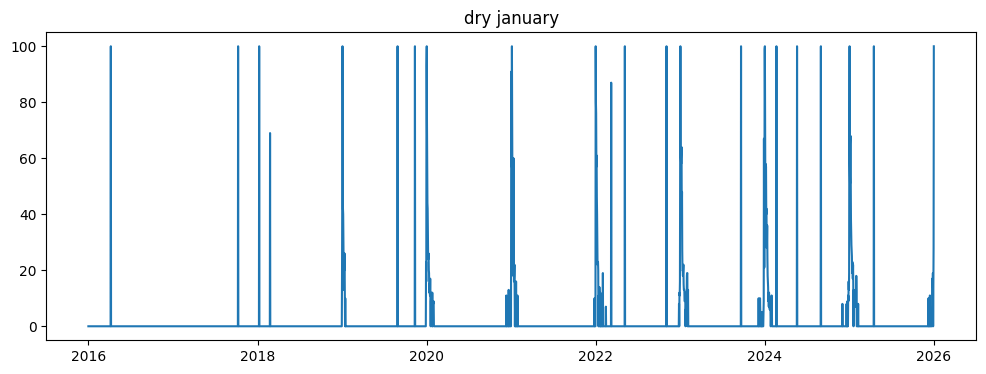

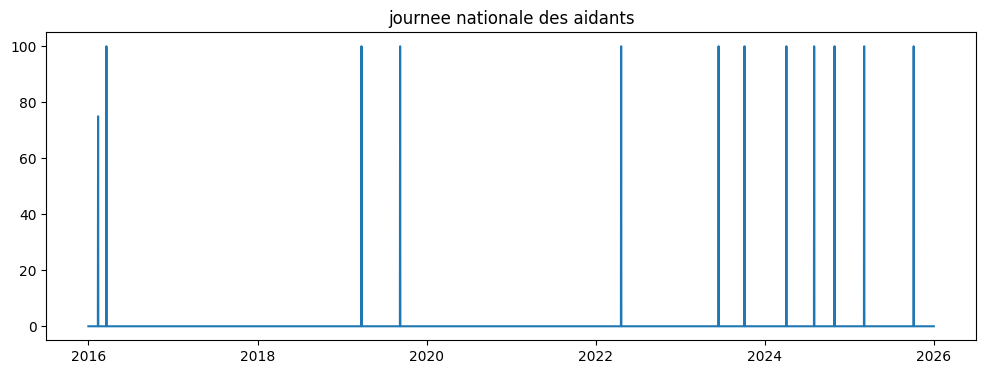

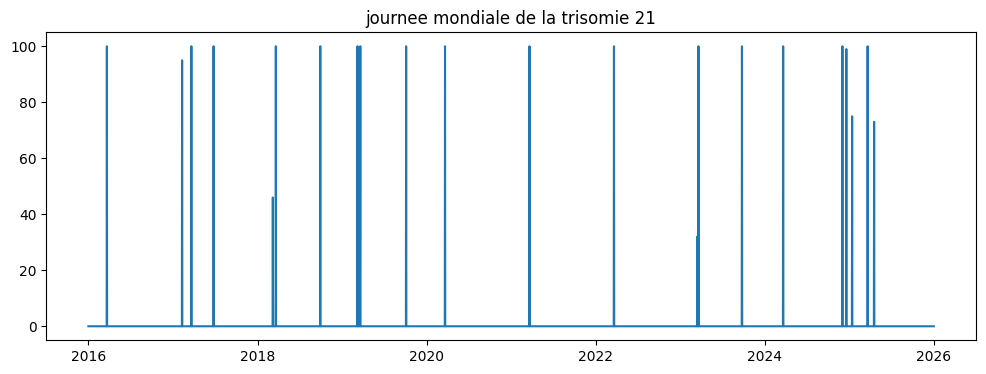

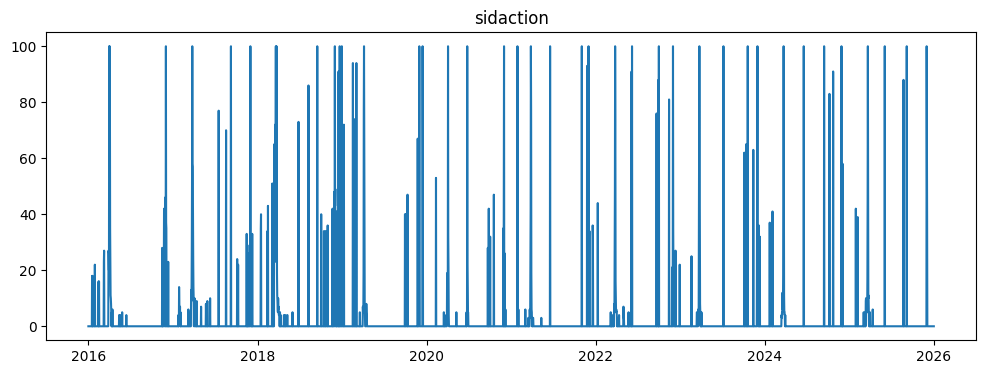

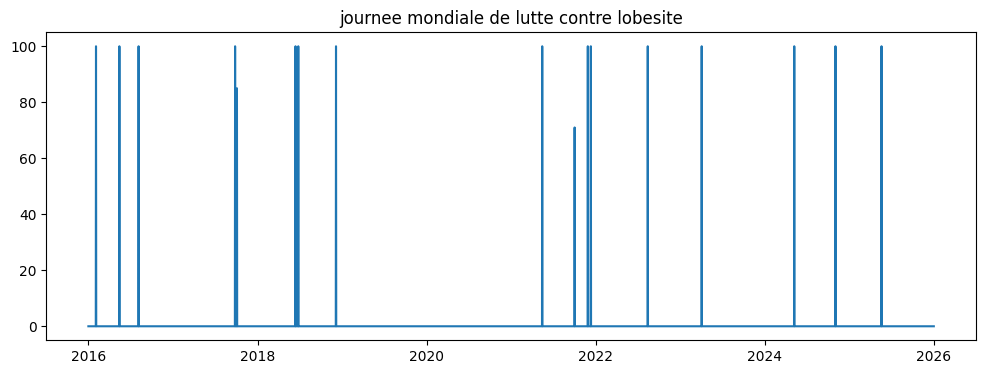

In [18]:
#première visualisation rapide
import matplotlib.pyplot as plt

for col in df.columns:
    plt.figure(figsize=(12,4))
    plt.plot(df.index, df[col])
    plt.title(col)
    plt.show()

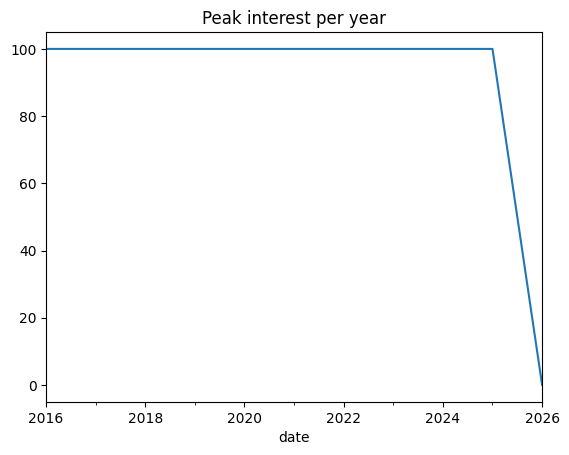

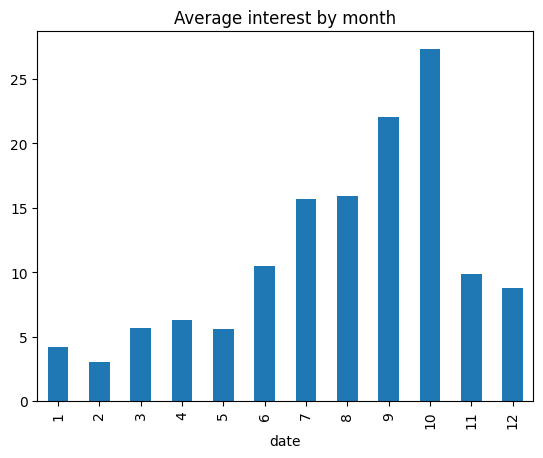

In [22]:
df["octobre rose"].resample("YE").max().plot()
plt.title("Peak interest per year")
plt.show()

df.groupby(df.index.month)["octobre rose"].mean().plot(kind="bar")
plt.title("Average interest by month")
plt.show()

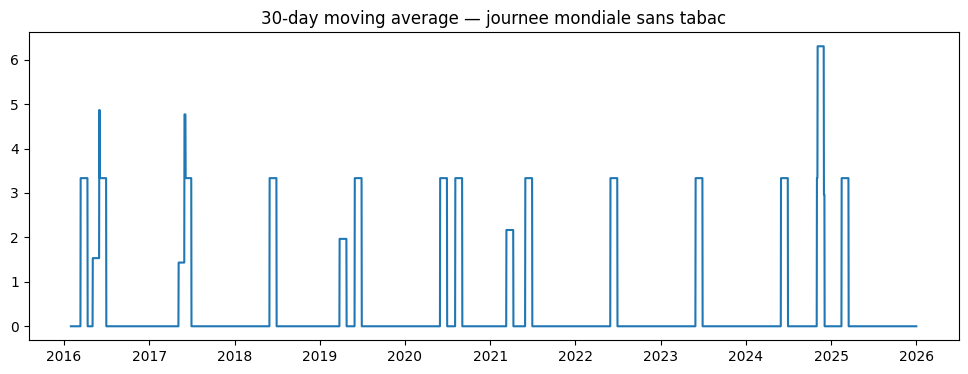

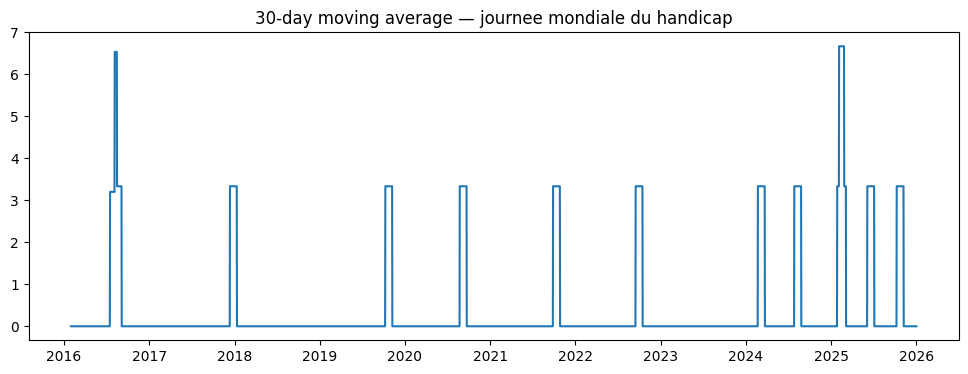

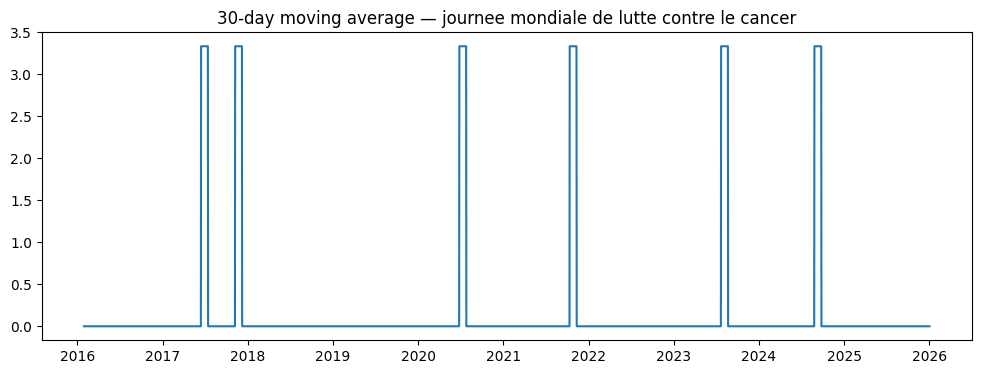

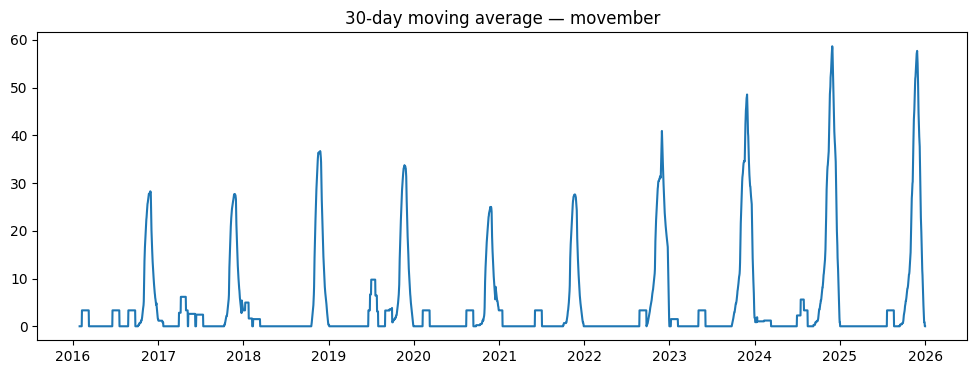

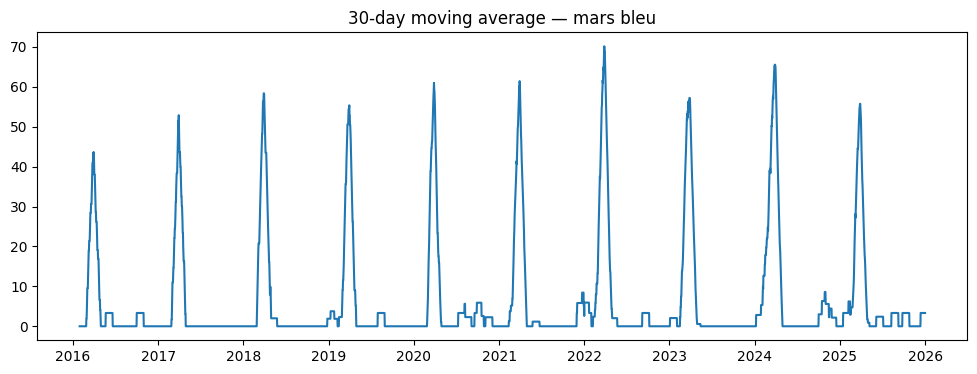

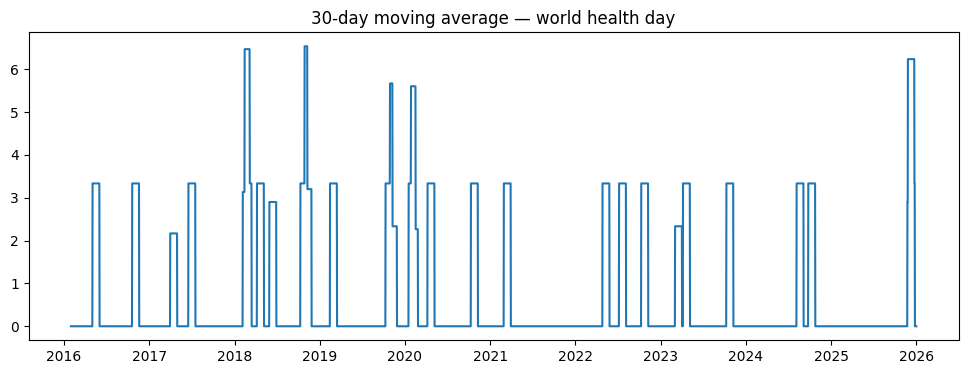

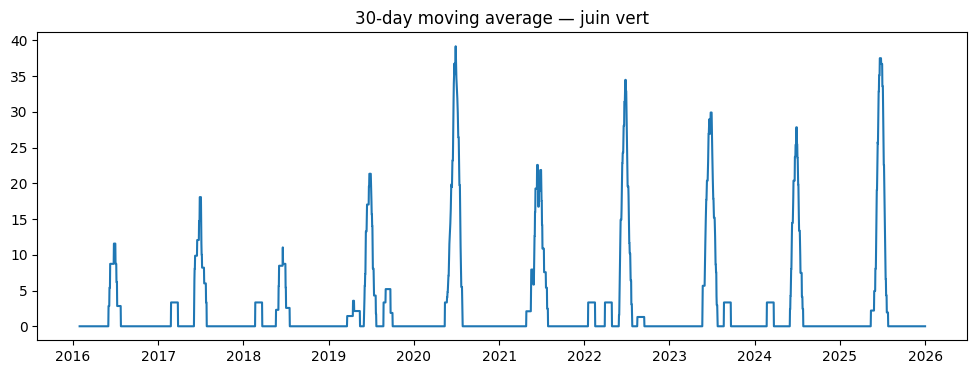

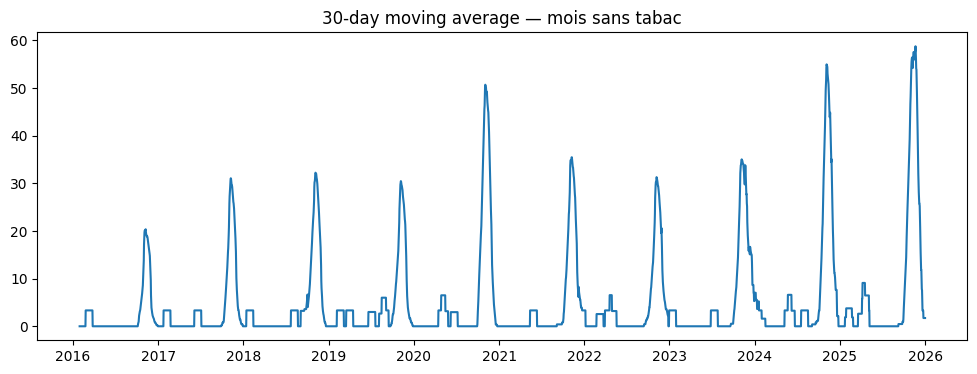

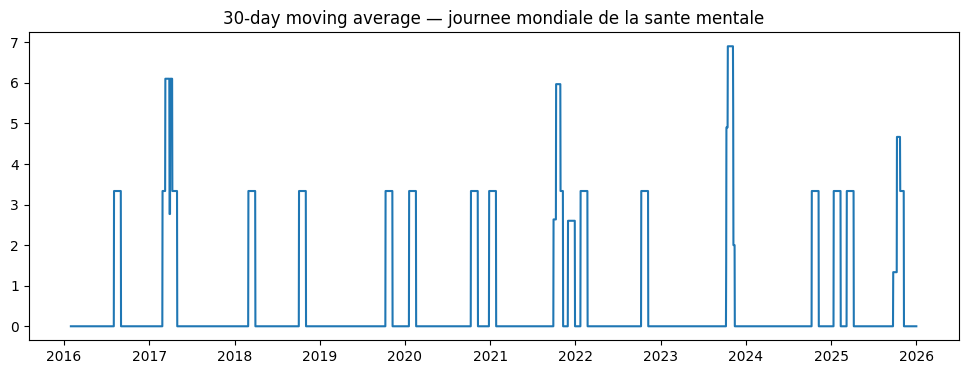

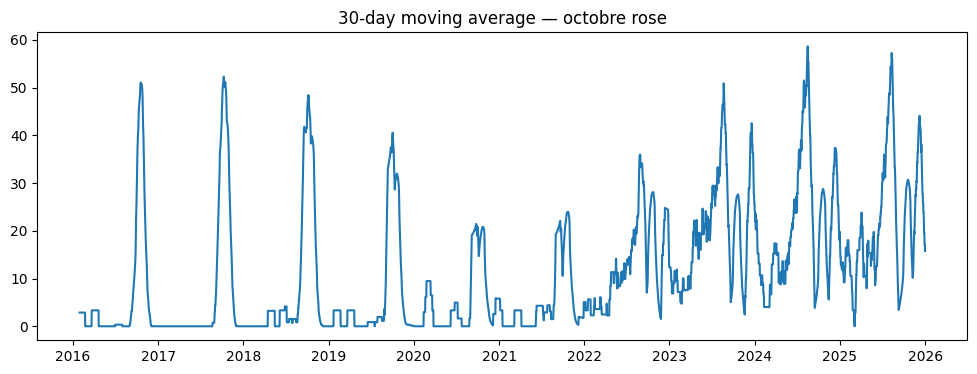

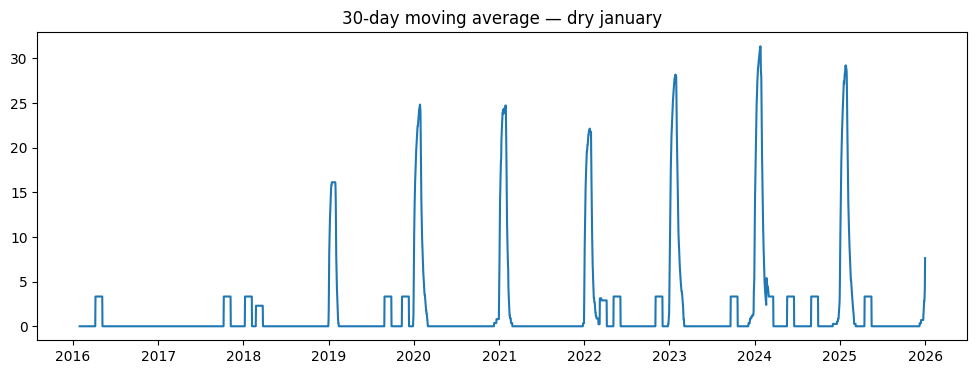

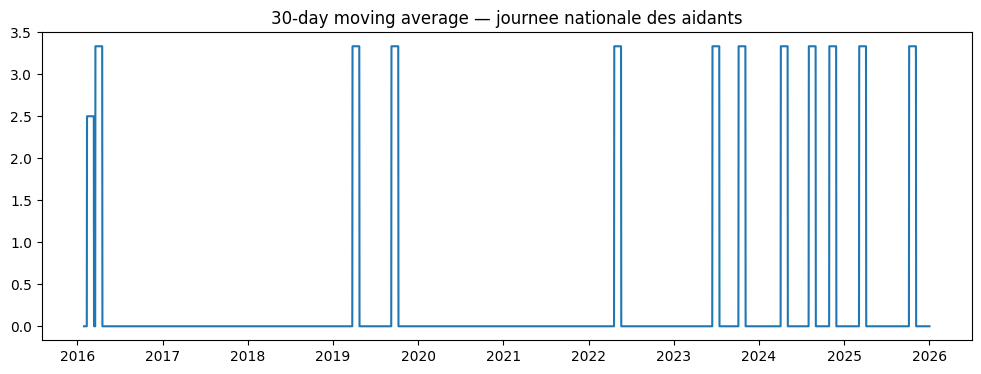

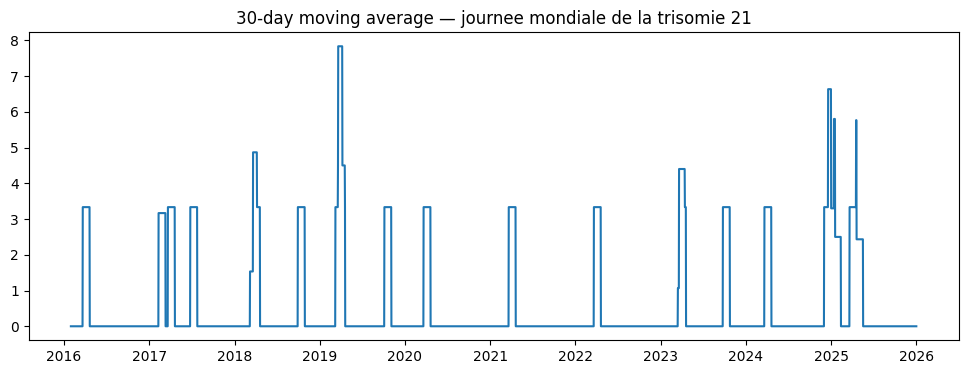

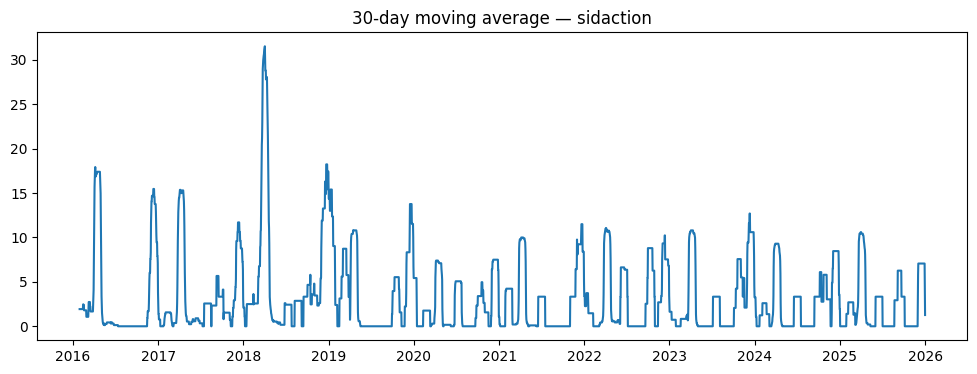

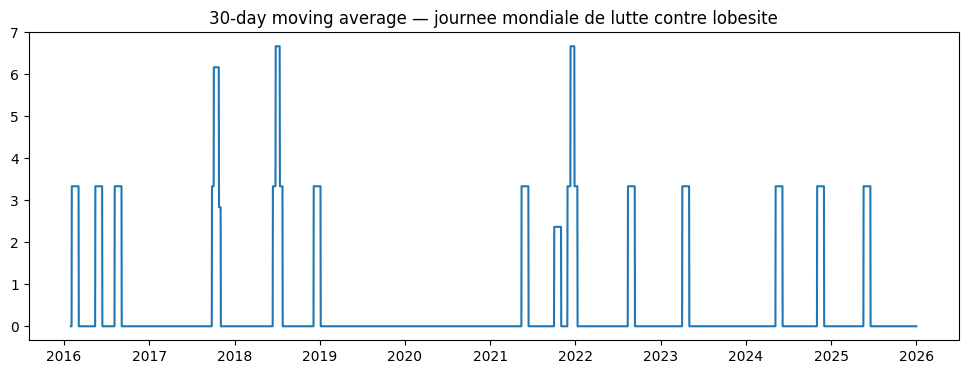

In [24]:
for keyword in df.columns:
    plt.figure(figsize=(12,4))
    plt.plot(df[keyword].rolling(30).mean())
    plt.title(f"30-day moving average — {keyword}")
    plt.show()

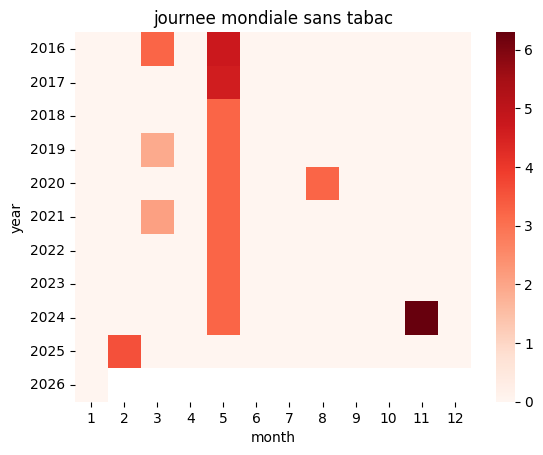

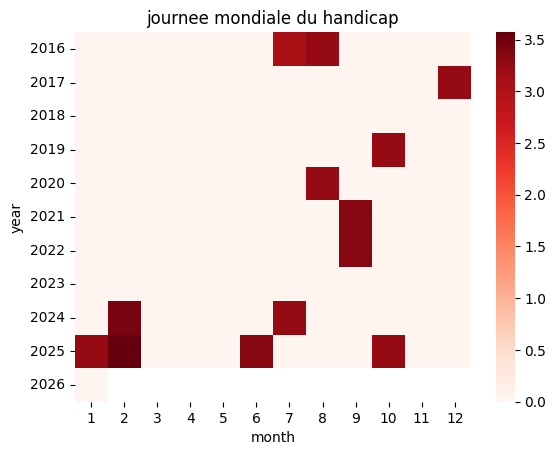

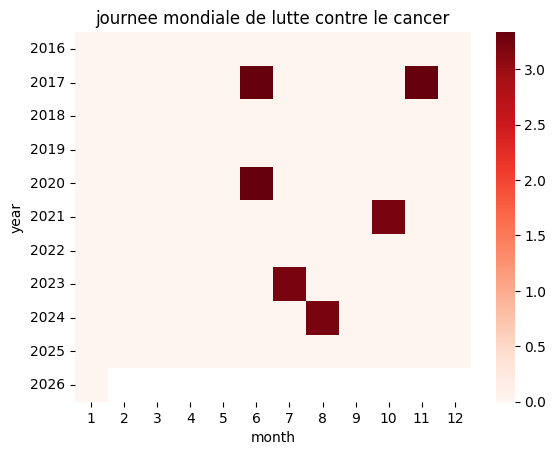

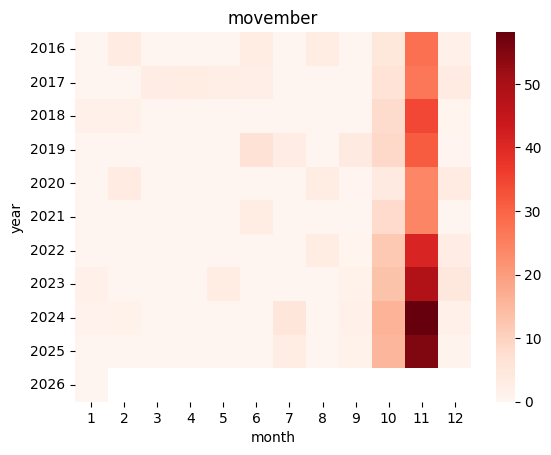

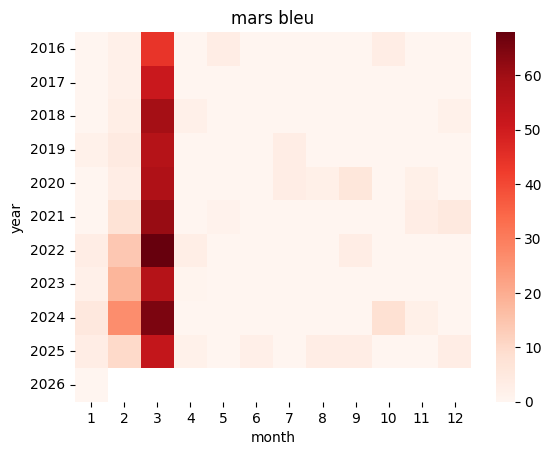

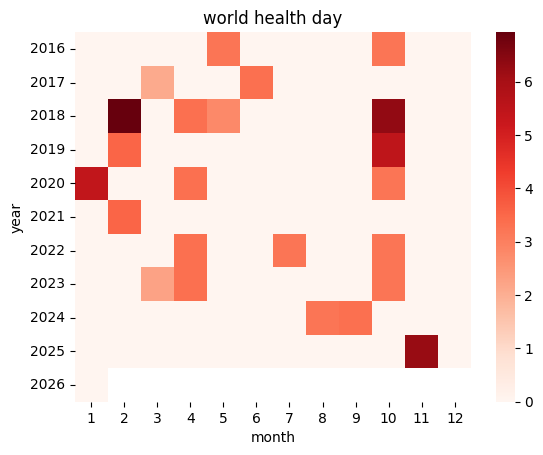

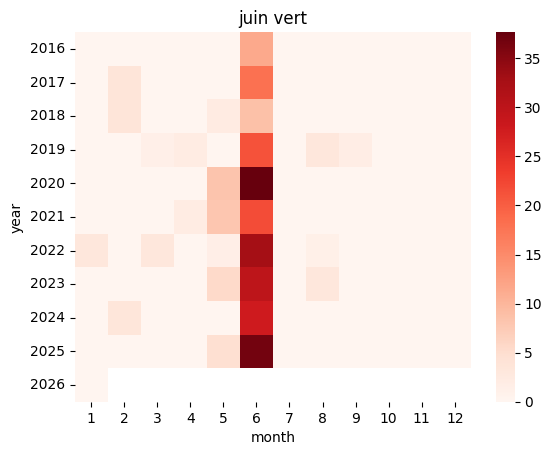

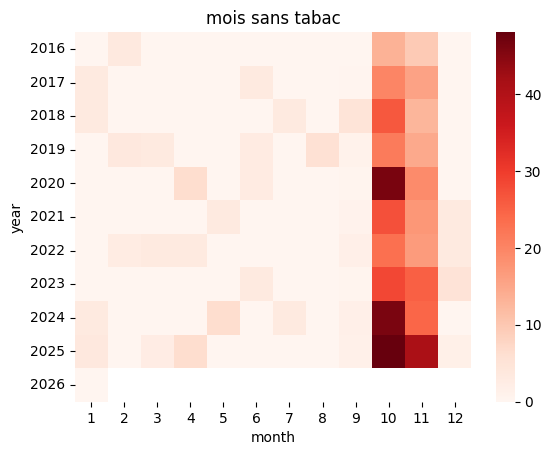

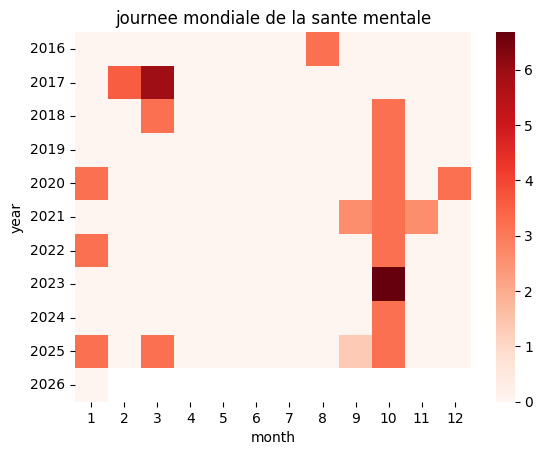

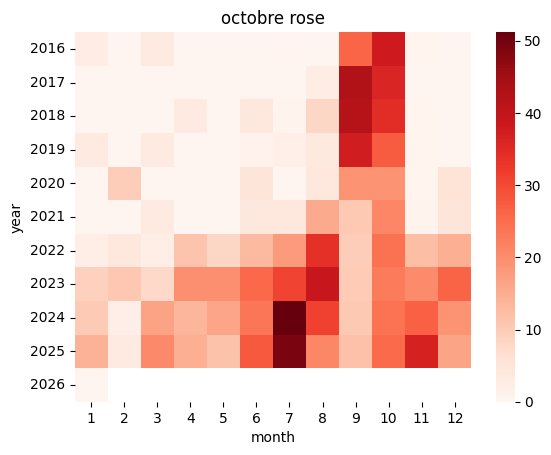

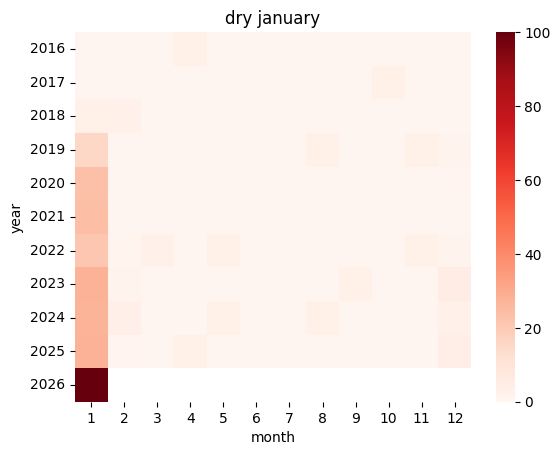

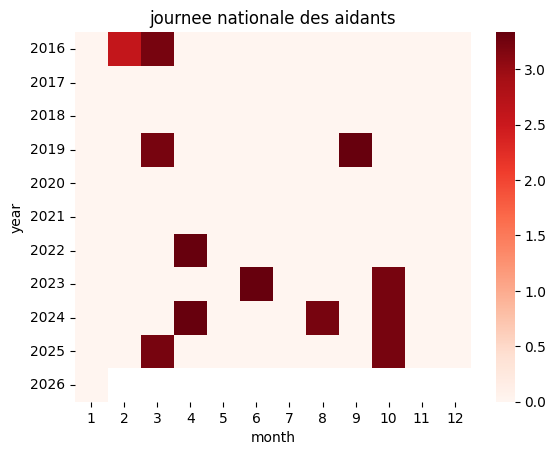

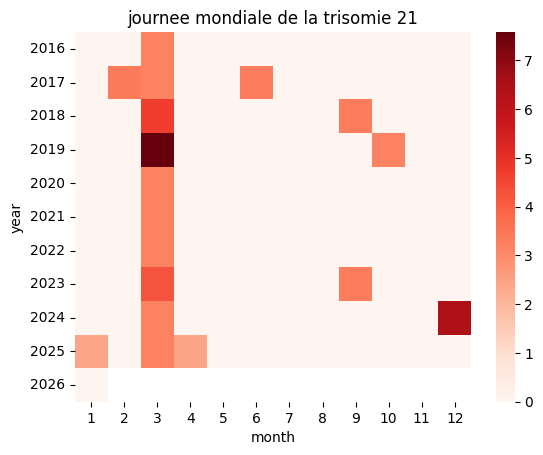

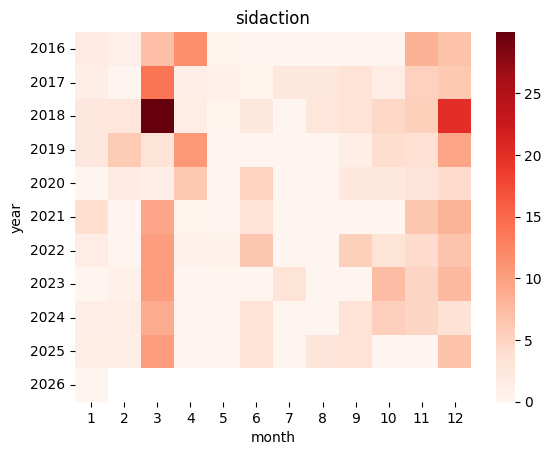

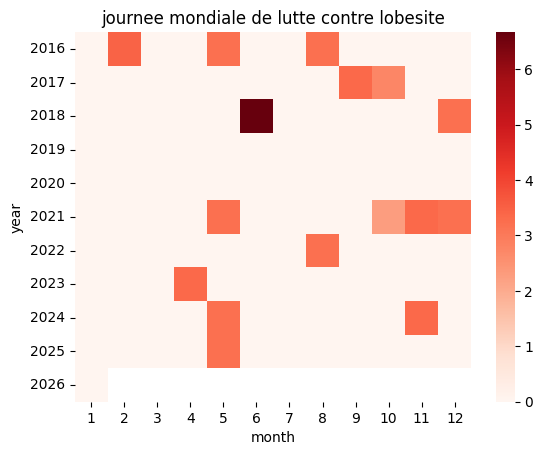

In [27]:
import seaborn as sns

for keyword in df.columns:
    monthly = df[keyword].resample("ME").mean()

    temp = monthly.to_frame()
    temp["year"] = temp.index.year
    temp["month"] = temp.index.month

    pivot = temp.pivot(index="year", columns="month", values=keyword)

    sns.heatmap(pivot, cmap="Reds")
    plt.title(keyword)
    plt.show()

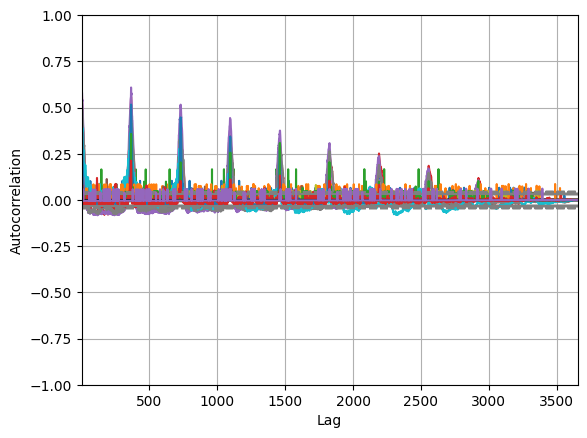

In [29]:
from pandas.plotting import autocorrelation_plot

for keyword in df.columns:
    autocorrelation_plot(df[keyword])